# Customer Fraud Detection – Binary Classification

**Target:** `is_fraudulent`  
- `0` = Not Fraudulent
- `1` = Fraudulent

This notebook follows the required workflow:

**Data → EDA → Cleaning → Date Features → Outlier Handling → Train/Test Split → Encoding → Scaling → SMOTE → Models → Evaluation → Comparison → Best Model → Final Predictions**

> **Important:** `customer_id` is used only as an identifier and is never supplied to the machine-learning models.

## 1. Import Libraries

In [9]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline as SkPipeline

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)

## 2. Load the Dataset

In [7]:
file_path = "customer_analytics_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (5000, 13)


,customer_id,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,customer_since,loyalty_score,churn_risk
0,CUST_8270,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,2024-06-05,50,0.20
1,CUST_1860,53,Female,USA,90.39,10,88,0,Electronics,12.3,2024-02-19,37,0.34
2,CUST_6390,73,Male,Australia,83.28,6,203,0,Sports,NaN,2024-04-16,65,0.05
3,CUST_6191,30,Other,Japan,109.90,9,346,1,Electronics,42.9,2020-07-08,93,0.19
4,CUST_6734,29,Female,Canada,269.38,16,342,0,Fashion,5.3,2025-04-09,79,0.15


In [10]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nDataset information:")
df.info()

Column names:
['customer_id', 'age', 'gender', 'country', 'avg_order_value', 'total_orders', 'last_purchase', 'is_fraudulent', 'preferred_category', 'email_open_rate', 'customer_since', 'loyalty_score', 'churn_risk']

Data types:


customer_id            object
age                     int64
gender                 object
country                object
avg_order_value       float64
total_orders            int64
last_purchase           int64
is_fraudulent           int64
preferred_category     object
email_open_rate       float64
customer_since         object
loyalty_score           int64
churn_risk            float64
dtype: object


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         5000 non-null   object 
 1   age                 5000 non-null   int64  
 2   gender              5000 non-null   object 
 3   country             5000 non-null   object 
 4   avg_order_value     4750 non-null   float64
 5   total_orders        5000 non-null   int64  
 6   last_purchase       5000 non-null   int64  
 7   is_fraudulent       5000 non-null   int64  
 8   preferred_category  5000 non-null   object 
 9   email_open_rate     4750 non-null   float64
 10  customer_since      5000 non-null   object 
 11  loyalty_score       5000 non-null   int64  
 12  churn_risk          5000 non-null   float64
dtypes: float64(3), int64(5), object(5)
memory usage: 507.9+ KB


## 3. EDA – Missing Values, Duplicates and Basic Statistics

In [11]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("Total duplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Missing values:


avg_order_value       250
email_open_rate       250
customer_id             0
age                     0
gender                  0
country                 0
total_orders            0
last_purchase           0
is_fraudulent           0
preferred_category      0
customer_since          0
loyalty_score           0
churn_risk              0
dtype: int64

Total duplicate rows: 0

Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,5000,3809,CUST_5780,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5000.0,NaN,NaN,NaN,48.1632,17.880797,18.0,33.0,48.0,64.0,79.0
gender,5000,3,Male,2278,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,5000,10,Australia,518,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_order_value,4750.0,NaN,NaN,NaN,108.442857,69.265559,10.66,57.805,93.19,142.1975,555.46
total_orders,5000.0,NaN,NaN,NaN,10.027,3.163838,0.0,8.0,10.0,12.0,23.0
last_purchase,5000.0,NaN,NaN,NaN,180.0732,104.926518,0.0,89.0,178.0,270.0,364.0
is_fraudulent,5000.0,NaN,NaN,NaN,0.0258,0.158554,0.0,0.0,0.0,0.0,1.0
preferred_category,5000,5,Beauty,1035,NaN,NaN,NaN,NaN,NaN,NaN,NaN
email_open_rate,4750.0,NaN,NaN,NaN,50.714842,29.098706,0.0,25.225,50.95,76.8,100.0


### Target Class Distribution

Fraud detection is normally an imbalanced classification problem. Accuracy alone can therefore be misleading. Recall and F1-score are especially important because failing to detect a fraudulent record is costly.

,Count,Percentage
is_fraudulent,,
0,4871,97.42
1,129,2.58


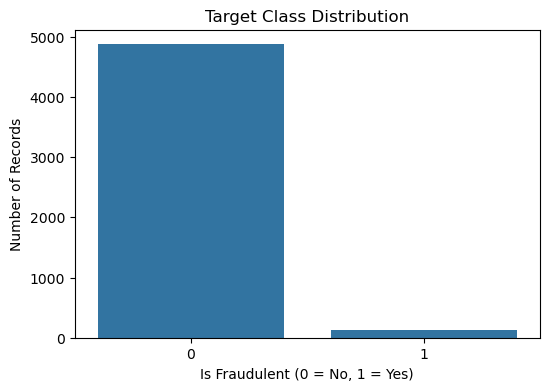

In [12]:
target_counts = df["is_fraudulent"].value_counts().sort_index()
target_percent = df["is_fraudulent"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})
display(target_summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="is_fraudulent")
plt.title("Target Class Distribution")
plt.xlabel("Is Fraudulent (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")
plt.show()

### Numerical Feature Distributions

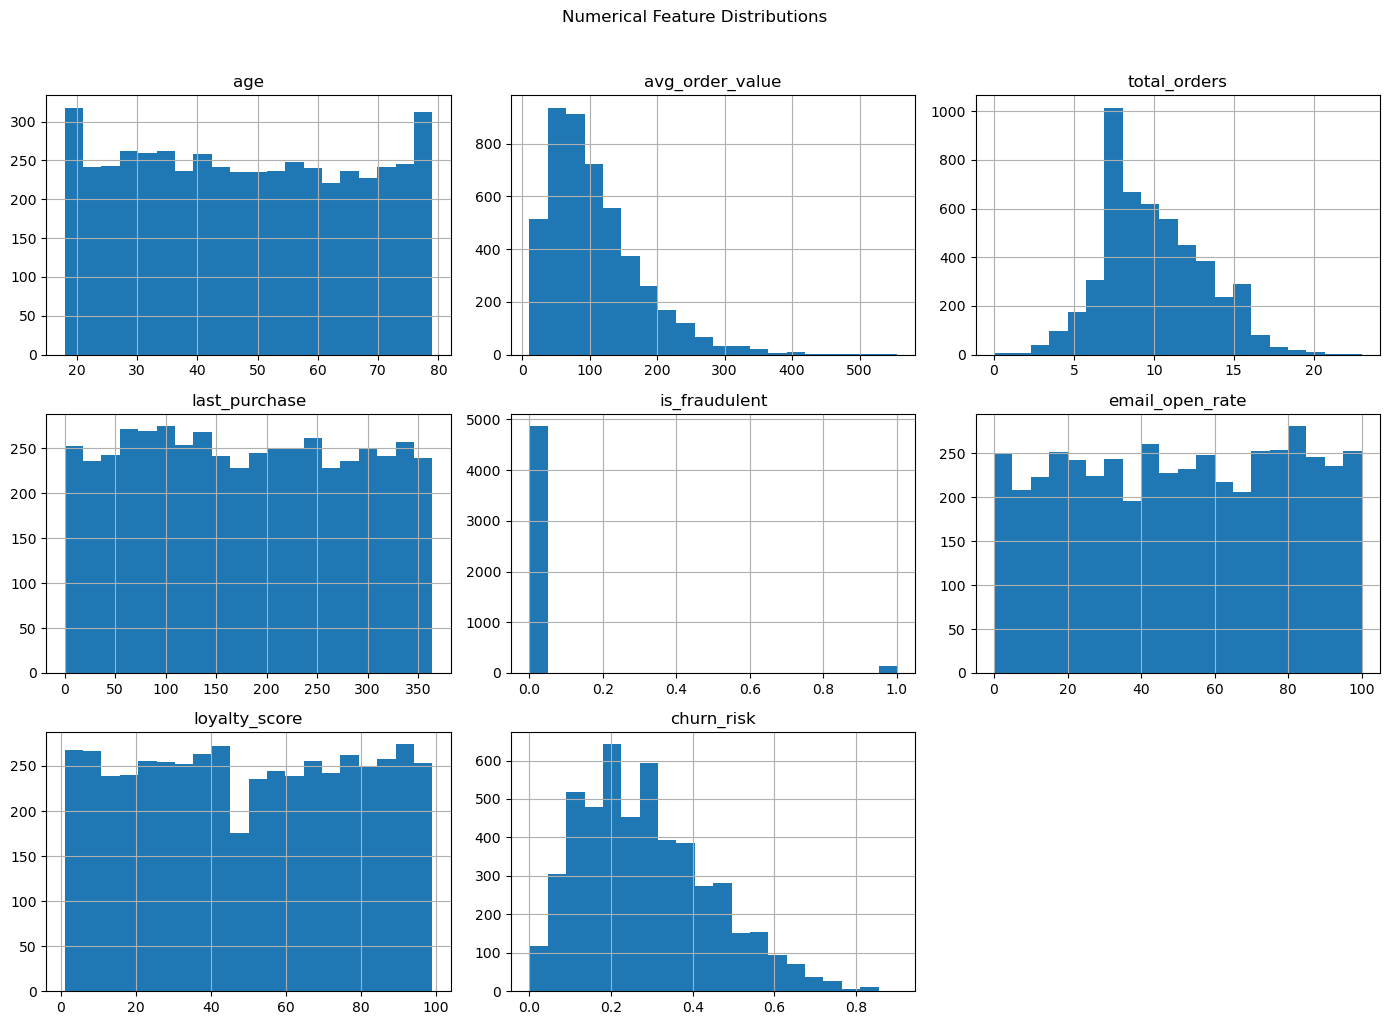

In [13]:
numeric_cols_eda = df.select_dtypes(include=np.number).columns.tolist()

df[numeric_cols_eda].hist(figsize=(14, 10), bins=20)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()

### Categorical Feature Distributions

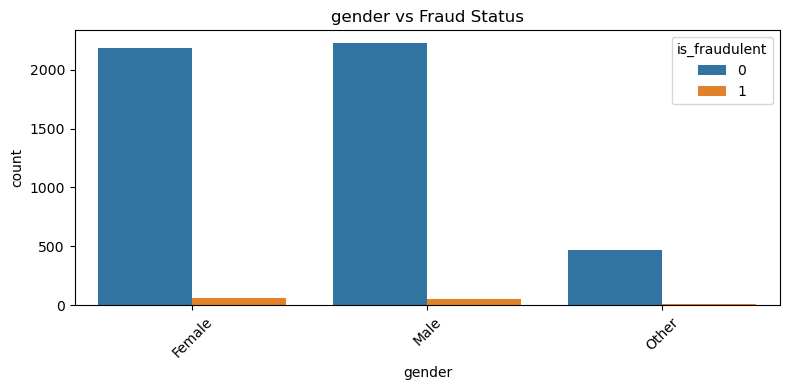

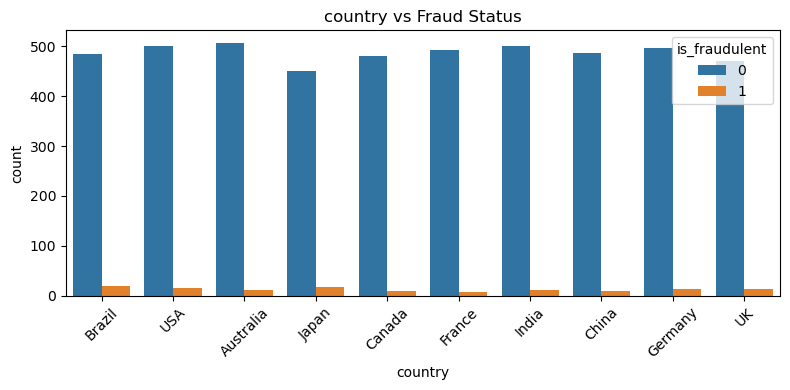

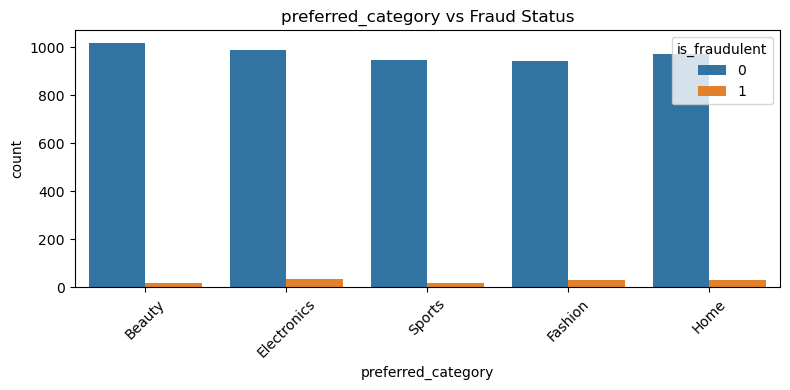

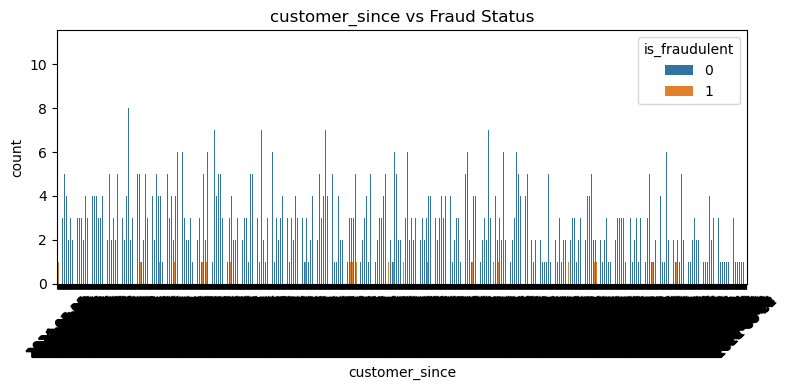

In [14]:
categorical_cols_eda = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols_eda:
    if col == "customer_id":
        continue
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue="is_fraudulent")
    plt.title(f"{col} vs Fraud Status")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 4. Outlier Detection

The IQR rule is used:

- Lower bound = Q1 − 1.5 × IQR
- Upper bound = Q3 + 1.5 × IQR

Outliers are **capped (winsorized)** rather than deleted so that potentially useful customer records are not unnecessarily removed. The bounds are learned from the training set only to avoid data leakage.

In [16]:
numeric_for_outliers = df.select_dtypes(include=np.number).columns.tolist()
numeric_for_outliers.remove("is_fraudulent")

outlier_summary = []

for col in numeric_for_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append([col, q1, q3, lower, upper, count])

outlier_summary = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Q1", "Q3", "Lower Bound", "Upper Bound", "Outlier Count"]
)
display(outlier_summary)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outlier Count
0,age,33.000,64.0000,-13.50000,110.50000,0
1,avg_order_value,57.805,142.1975,-68.78375,268.78625,137
2,total_orders,8.000,12.0000,2.00000,18.00000,42
3,last_purchase,89.000,270.0000,-182.50000,541.50000,0
4,email_open_rate,25.225,76.8000,-52.13750,154.16250,0
5,loyalty_score,25.000,75.0000,-50.00000,150.00000,0
6,churn_risk,0.160,0.3900,-0.18500,0.73500,37


## 5. Date Feature Engineering

`customer_since` is a date, so it is converted into useful numerical features:

- `customer_since_year`
- `customer_since_month`
- `customer_tenure_days`

The original date column is then removed because machine-learning models need numerical/categorical features rather than a raw date string.

In [18]:
data = df.copy()

data["customer_since"] = pd.to_datetime(data["customer_since"], errors="coerce")

reference_date = data["customer_since"].max()

data["customer_since_year"] = data["customer_since"].dt.year
data["customer_since_month"] = data["customer_since"].dt.month
data["customer_tenure_days"] = (
    reference_date - data["customer_since"]
).dt.days

# Keep customer_id separately for identification/final prediction output.
customer_ids = data["customer_id"].copy()

# Remove identifier and raw date from model features.
data = data.drop(columns=["customer_id", "customer_since"])

print("Reference date used for tenure:", reference_date.date())
display(data.head())

Reference date used for tenure: 2025-06-28


,age,gender,country,avg_order_value,total_orders,last_purchase,is_fraudulent,preferred_category,email_open_rate,loyalty_score,churn_risk,customer_since_year,customer_since_month,customer_tenure_days
0,30,Female,Brazil,101.08,8,176,1,Beauty,25.6,50,0.20,2024,6,388
1,53,Female,USA,90.39,10,88,0,Electronics,12.3,37,0.34,2024,2,495
2,73,Male,Australia,83.28,6,203,0,Sports,NaN,65,0.05,2024,4,438
3,30,Other,Japan,109.90,9,346,1,Electronics,42.9,93,0.19,2020,7,1816
4,29,Female,Canada,269.38,16,342,0,Fashion,5.3,79,0.15,2025,4,80


## 6. Separate Features (X) and Target (y)

`customer_id` has already been removed because it is only an identifier and could introduce meaningless patterns into the model.

In [19]:
X = data.drop(columns=["is_fraudulent"])
y = data["is_fraudulent"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeatures:")
print(X.columns.tolist())

X shape: (5000, 13)
y shape: (5000,)

Features:
['age', 'gender', 'country', 'avg_order_value', 'total_orders', 'last_purchase', 'preferred_category', 'email_open_rate', 'loyalty_score', 'churn_risk', 'customer_since_year', 'customer_since_month', 'customer_tenure_days']


## 7. Train/Test Split

A **stratified 80/20 split** is used so that the very small fraudulent class is represented in both training and testing sets in approximately the same proportion.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTesting target distribution:")
display(y_test.value_counts())

# IDs are retained only for final prediction reporting.
test_customer_ids = customer_ids.loc[X_test.index].reset_index(drop=True)

Training shape: (4000, 13)
Testing shape: (1000, 13)

Training target distribution:


is_fraudulent
0    3897
1     103
Name: count, dtype: int64


Testing target distribution:


is_fraudulent
0    974
1     26
Name: count, dtype: int64

## 8. Outlier Capping Using Training Data Only

The IQR limits are calculated from `X_train`. The same limits are then applied to both training and test data. This prevents information from the test set from influencing preprocessing.

In [21]:
numeric_features_raw = X_train.select_dtypes(include=np.number).columns.tolist()

iqr_bounds = {}

for col in numeric_features_raw:
    q1 = X_train[col].quantile(0.25)
    q3 = X_train[col].quantile(0.75)
    iqr = q3 - q1
    iqr_bounds[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)

def cap_outliers(X_data, bounds):
    X_copy = X_data.copy()
    for col, (lower, upper) in bounds.items():
        X_copy[col] = X_copy[col].clip(lower=lower, upper=upper)
    return X_copy

X_train = cap_outliers(X_train, iqr_bounds)
X_test = cap_outliers(X_test, iqr_bounds)

print("Outlier capping completed.")

Outlier capping completed.


## 9. Encoding and Feature Scaling

### Encoding
**One-Hot Encoding** is used for categorical variables because features such as gender, country and preferred category are nominal categories. One-hot encoding avoids incorrectly implying an order between categories.

### Scaling
**StandardScaler** is selected because it transforms numerical features to approximately zero mean and unit variance. This puts variables measured on different scales into a comparable range and is also a standard preprocessing choice for SMOTE-based workflows.

Tree algorithms do not strictly require scaling, but scaling is retained here to satisfy the assignment's preprocessing requirement and to keep a consistent preprocessing pipeline.

In [22]:
numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include="object").columns.tolist()

numeric_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = SkPipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'avg_order_value', 'total_orders', 'last_purchase', 'email_open_rate', 'loyalty_score', 'churn_risk', 'customer_since_year', 'customer_since_month', 'customer_tenure_days']
Categorical features: ['gender', 'country', 'preferred_category']


## 10. Handling Class Imbalance with SMOTE

The target is highly imbalanced, so **SMOTE (Synthetic Minority Over-sampling Technique)** is used.

A key point is that SMOTE is placed **inside the imbalanced-learn pipeline**, after preprocessing. Therefore, synthetic observations are generated only from the training data. The test set remains untouched and represents the real evaluation distribution.

In [23]:
imbalance_ratio = y_train.value_counts(normalize=True)

print("Training class percentages:")
display((imbalance_ratio * 100).round(2))

if y_train.value_counts().min() / y_train.value_counts().max() < 0.5:
    print("Classes are imbalanced -> SMOTE will be applied.")
else:
    print("Classes are reasonably balanced -> SMOTE is not necessary.")

Training class percentages:


is_fraudulent
0    97.42
1     2.58
Name: proportion, dtype: float64

Classes are imbalanced -> SMOTE will be applied.


## 11. Define the Required Classification Models

The following required algorithms are applied:

1. Decision Tree
2. Random Forest
3. XGBoost

The random state is fixed for reproducibility.

In [26]:
models = {
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=8,
        min_samples_leaf=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

## 12. Train Models and Evaluate Performance

The evaluation metrics are:

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** Of the records predicted as fraud, how many were actually fraud.
- **Recall:** Of the actual fraud records, how many were detected.
- **F1-score:** Harmonic mean of precision and recall.
- **Confusion Matrix:** Shows TP, TN, FP and FN.
- **Classification Report:** Provides class-wise precision, recall and F1-score.

For fraud detection, **F1-score and recall are more informative than accuracy alone** because the fraudulent class is very small.

In [27]:
results = []
predictions = {}
probabilities = {}
pipelines = {}

for name, model in models.items():

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=RANDOM_STATE)),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    pipelines[name] = pipe
    predictions[name] = y_pred
    probabilities[name] = y_prob

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    })

comparison_df = pd.DataFrame(results).sort_values(
    by=["F1-Score", "Recall", "Precision"],
    ascending=False
).reset_index(drop=True)

display(comparison_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.771,0.0235,0.1923,0.0418
1,Random Forest,0.974,0.0000,0.0000,0.0000


## 13. Confusion Matrices

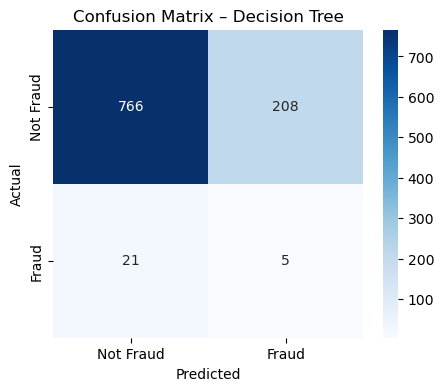

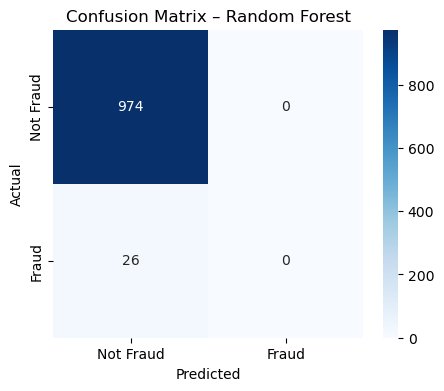

In [29]:
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Fraud", "Fraud"],
        yticklabels=["Not Fraud", "Fraud"]
    )
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 14. Classification Reports

In [30]:
for name, y_pred in predictions.items():
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Not Fraud", "Fraud"],
        zero_division=0
    ))

Decision Tree
              precision    recall  f1-score   support

   Not Fraud       0.97      0.79      0.87       974
       Fraud       0.02      0.19      0.04        26

    accuracy                           0.77      1000
   macro avg       0.50      0.49      0.46      1000
weighted avg       0.95      0.77      0.85      1000

Random Forest
              precision    recall  f1-score   support

   Not Fraud       0.97      1.00      0.99       974
       Fraud       0.00      0.00      0.00        26

    accuracy                           0.97      1000
   macro avg       0.49      0.50      0.49      1000
weighted avg       0.95      0.97      0.96      1000



## 15. Model Comparison

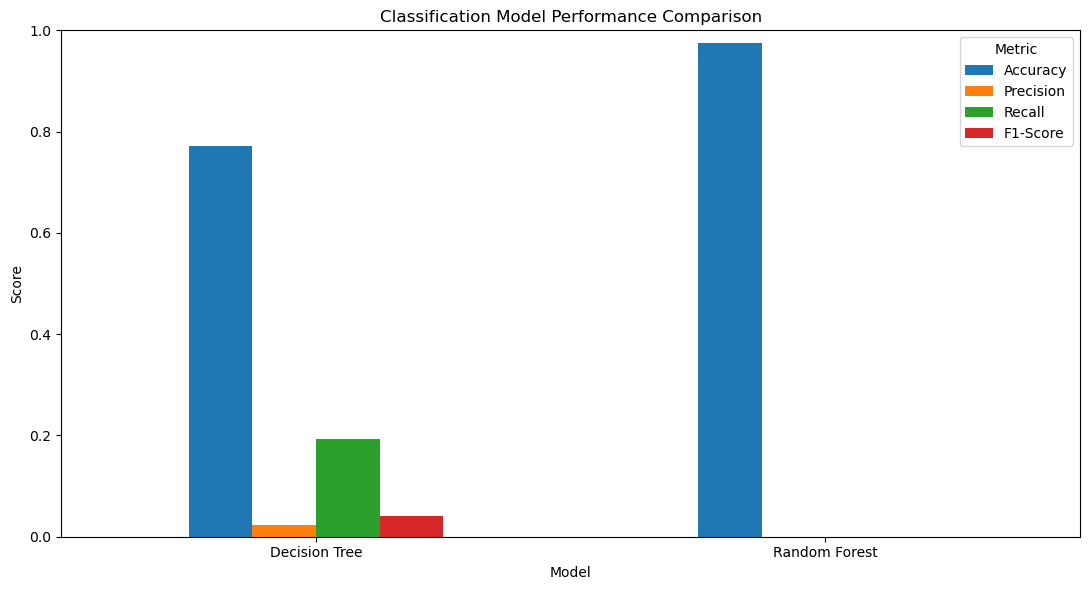

,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.771,0.0235,0.1923,0.0418
1,Random Forest,0.974,0.0000,0.0000,0.0000


In [31]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]

comparison_plot = comparison_df.set_index("Model")[metrics_to_plot]

comparison_plot.plot(kind="bar", figsize=(11, 6))
plt.title("Classification Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

display(comparison_df.round(4))

## 16. Select the Best Model

Because this is **fraud detection**, the best model is selected primarily using **F1-score**, with recall and precision used as supporting criteria. This is more appropriate than selecting a model only because it has the highest accuracy.

The code below automatically identifies the best model rather than hard-coding a result.

In [32]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = pipelines[best_model_name]
best_pred = predictions[best_model_name]
best_prob = probabilities[best_model_name]

print("Best-performing model:", best_model_name)
print("\nFinal performance:")
display(comparison_df.iloc[[0]].round(4))

print("\nBest model classification report:")
print(classification_report(
    y_test,
    best_pred,
    target_names=["Not Fraud", "Fraud"],
    zero_division=0
))

Best-performing model: Decision Tree

Final performance:


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.771,0.0235,0.1923,0.0418



Best model classification report:
              precision    recall  f1-score   support

   Not Fraud       0.97      0.79      0.87       974
       Fraud       0.02      0.19      0.04        26

    accuracy                           0.77      1000
   macro avg       0.50      0.49      0.46      1000
weighted avg       0.95      0.77      0.85      1000



## 17. Final Prediction Results

The `customer_id` is shown here only to identify records. It was **not used as a model feature**.

The output contains:

- Customer ID
- Actual fraud status
- Predicted fraud status
- Fraud probability

In [33]:
final_predictions = pd.DataFrame({
    "customer_id": test_customer_ids,
    "actual_is_fraudulent": y_test.reset_index(drop=True),
    "predicted_is_fraudulent": best_pred,
    "fraud_probability": best_prob
})

final_predictions["prediction_correct"] = (
    final_predictions["actual_is_fraudulent"]
    == final_predictions["predicted_is_fraudulent"]
)

display(final_predictions.head(20))

print("Total test predictions:", len(final_predictions))
print("Predicted fraudulent records:",
      final_predictions["predicted_is_fraudulent"].sum())

,customer_id,actual_is_fraudulent,predicted_is_fraudulent,fraud_probability,prediction_correct
0,CUST_1966,0,0,0.000000,True
1,CUST_2048,0,0,0.030303,True
2,CUST_7094,0,1,0.550879,False
3,CUST_9849,0,0,0.067568,True
4,CUST_3237,0,1,0.550879,False
5,CUST_2504,0,0,0.213604,True
6,CUST_1599,0,0,0.007553,True
7,CUST_2774,0,0,0.000000,True
8,CUST_5666,0,0,0.000000,True
9,CUST_2138,0,0,0.000000,True


Total test predictions: 1000
Predicted fraudulent records: 213


## 18. Conclusion

### Preprocessing Decisions

- **Missing values:** Numerical missing values are filled using the median; categorical missing values use the most frequent category.
- **Duplicates:** Duplicate rows are checked; the dataset contains no duplicate rows.
- **Outliers:** IQR-based capping is used rather than deleting observations. The IQR limits are learned only from training data.
- **Date:** `customer_since` is converted into year, month and customer tenure in days.
- **Identifier:** `customer_id` is excluded from model training.
- **Encoding:** One-Hot Encoding is used for nominal categorical variables.
- **Scaling:** StandardScaler is used to standardize numerical variables.
- **Class imbalance:** SMOTE is applied only to the training portion through an imbalanced-learn pipeline.
- **Models:** Decision Tree, Random Forest and XGBoost are trained and compared.
- **Best model:** Selected using F1-score because fraud detection is an imbalanced classification problem.

### Important Interpretation

If the fraud models produce low precision/recall/F1 despite preprocessing and SMOTE, this should **not** be hidden. It means that the available customer features may not contain enough predictive information to reliably distinguish fraudulent from non-fraudulent records. In that situation, a high accuracy score can simply reflect the large majority class.

For a production fraud system, additional fraud-related features, better labels, threshold tuning, cross-validation and cost-sensitive learning would normally be investigated.